<a href="https://colab.research.google.com/github/msb24/ModelWatch-Wk-5/blob/main/MSB_ModelWatch_Week5_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ModelWatch Week 5 MVP
### Rapid prototype for a Support RAG assistant incident workflow

**Prototype question:** Can a small batch of monitoring telemetry turn into an owner-readable incident without overstating what the data proves?

This notebook uses **illustrative data** and a deliberately small rules-based detector. It does not connect to a production system or claim that a knowledge-base update caused the quality decline. The goal is to test the ModelWatch workflow from monitoring data to an incident summary that a product manager can review.


## Prompt 1 outcome
I first asked GPT-5.6 Sol to audit the existing prototype rather than rebuild it, prioritize coding and metric-design errors, and keep the MVP small enough for me to understand. The audit identified denominator and aggregation problems in the monitoring metrics. I revised the telemetry to preserve raw counts, separated retrieval evidence from CSAT evidence, corrected the latency label and incident logic, and reran the prototype before adding functionality.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.patches import FancyBboxPatch

pd.set_option('display.max_columns', None)

# Illustrative telemetry for one Support RAG Assistant.
# Raw counts make the metric calculations visible and auditable.
data = pd.DataFrame({
    'date': pd.to_datetime([
        '2026-09-14','2026-09-15','2026-09-16','2026-09-17',
        '2026-09-18','2026-09-19','2026-09-20','2026-09-21'
    ]),
    'period': ['baseline'] * 4 + ['current'] * 4,

    # CSAT evidence
    'rated_conversations': [60, 60, 60, 60, 60, 58, 61, 59],
    'positive_ratings':    [50, 50, 49, 50, 46, 43, 45, 42],

    # Retrieval evidence
    'retrieval_attempts':  [110, 100, 120, 105, 115, 100, 125, 105],
    'retrieval_successes': [100,  90, 107,  95,  94,  80,  98,  80],

    # Citation evidence
    'cited_answers': [90, 92, 88, 91, 89, 90, 87, 88],
    'citation_mismatch_flags': [1, 2, 1, 2, 4, 5, 6, 7],

    # Performance and change context
    'daily_p95_latency_s': [1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8],
    'kb_updates': [0, 0, 0, 0, 1, 0, 0, 0]
})

# Daily percentages are for display and charting.
# Period-level metrics will be calculated from pooled raw counts later.
data['csat_pct'] = (
    100 * data['positive_ratings'] / data['rated_conversations']
)

data['retrieval_hit_pct'] = (
    100 * data['retrieval_successes'] / data['retrieval_attempts']
)

data['citation_mismatch_pct'] = (
    100 * data['citation_mismatch_flags'] / data['cited_answers']
)

data.to_csv('modelwatch_monitoring_data.csv', index=False)

data.round(2)

,date,period,rated_conversations,positive_ratings,retrieval_attempts,retrieval_successes,cited_answers,citation_mismatch_flags,daily_p95_latency_s,kb_updates,csat_pct,retrieval_hit_pct,citation_mismatch_pct
0,2026-09-14,baseline,60,50,110,100,90,1,1.8,0,83.33,90.91,1.11
1,2026-09-15,baseline,60,50,100,90,92,2,1.8,0,83.33,90.00,2.17
2,2026-09-16,baseline,60,49,120,107,88,1,1.8,0,81.67,89.17,1.14
3,2026-09-17,baseline,60,50,105,95,91,2,1.8,0,83.33,90.48,2.20
4,2026-09-18,current,60,46,115,94,89,4,1.8,1,76.67,81.74,4.49
5,2026-09-19,current,58,43,100,80,90,5,1.8,0,74.14,80.00,5.56
6,2026-09-20,current,61,45,125,98,87,6,1.8,0,73.77,78.40,6.90
7,2026-09-21,current,59,42,105,80,88,7,1.8,0,71.19,76.19,7.95


## Prompt 2 outcome
I asked GPT-5.6 Sol to make the monitoring metrics mathematically defensible before adding new functionality. The audit confirmed that CSAT and retrieval success should be calculated from separate pooled numerators and denominators rather than averaging daily percentages or reusing the same denominator. Citation mismatches were also normalized by cited answers. Because the available latency observations were daily p95 values rather than request-level latency records, I labeled the aggregate as median daily p95 latency rather than implying that it represented a true period-wide p95.


In [ ]:
REQUIRED_COLUMNS = [
    'date',
    'period',
    'rated_conversations',
    'positive_ratings',
    'retrieval_attempts',
    'retrieval_successes',
    'cited_answers',
    'citation_mismatch_flags',
    'daily_p95_latency_s',
    'kb_updates'
]

def validate_monitoring_data(df):
    problems = []

    # Required fields must exist.
    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing_cols:
        return [f"Missing required columns: {', '.join(missing_cols)}"]

    # Required evidence cannot contain missing values.
    if df[REQUIRED_COLUMNS].isna().any().any():
        bad = (
            df[REQUIRED_COLUMNS]
            .columns[df[REQUIRED_COLUMNS].isna().any()]
            .tolist()
        )
        problems.append(f"Missing values in: {', '.join(bad)}")

    # One monitoring record per date for this small MVP.
    if df['date'].duplicated().any():
        problems.append("Dates must be unique")

    if not df['period'].isin(['baseline', 'current']).all():
        problems.append("Period must be either baseline or current")

    if set(df['period'].unique()) != {'baseline', 'current'}:
        problems.append("Both baseline and current periods are required")

    # Denominators must be usable.
    for column in [
        'rated_conversations',
        'retrieval_attempts',
        'cited_answers'
    ]:
        if (df[column] <= 0).any():
            problems.append(f"{column} must be greater than 0")

    # Counts cannot be negative.
    for column in [
        'positive_ratings',
        'retrieval_successes',
        'citation_mismatch_flags',
        'kb_updates'
    ]:
        if (df[column] < 0).any():
            problems.append(f"{column} cannot be negative")

    # Numerators cannot exceed their denominators.
    if (df['positive_ratings'] > df['rated_conversations']).any():
        problems.append(
            "positive_ratings cannot exceed rated_conversations"
        )

    if (df['retrieval_successes'] > df['retrieval_attempts']).any():
        problems.append(
            "retrieval_successes cannot exceed retrieval_attempts"
        )

    if (df['citation_mismatch_flags'] > df['cited_answers']).any():
        problems.append(
            "citation_mismatch_flags cannot exceed cited_answers"
        )

    if (df['daily_p95_latency_s'] < 0).any():
        problems.append("Latency cannot be negative")

    return problems


validation_problems = validate_monitoring_data(data)

print(
    'PASS - monitoring data is valid'
    if not validation_problems
    else validation_problems
)

PASS - monitoring data is valid


In [ ]:
def summarize_period(df, period):
    part = df[df['period'] == period].copy()

    return {
        # CSAT is pooled from raw ratings.
        'rated_conversations':
            int(part['rated_conversations'].sum()),

        'csat_pct':
            100
            * part['positive_ratings'].sum()
            / part['rated_conversations'].sum(),

        # Retrieval gets its own denominator.
        'retrieval_attempts':
            int(part['retrieval_attempts'].sum()),

        'retrieval_hit_pct':
            100
            * part['retrieval_successes'].sum()
            / part['retrieval_attempts'].sum(),

        # Keep both mismatch count and rate.
        'cited_answers':
            int(part['cited_answers'].sum()),

        'citation_mismatch_flags':
            int(part['citation_mismatch_flags'].sum()),

        'citation_mismatch_pct':
            100
            * part['citation_mismatch_flags'].sum()
            / part['cited_answers'].sum(),

        # These are daily p95 observations.
        # Median daily p95 is an honest aggregate label.
        'median_daily_p95_latency_s':
            float(part['daily_p95_latency_s'].median()),

        'kb_updates':
            int(part['kb_updates'].sum())
    }


# Prototype thresholds are intentionally visible.
# They are product rules for testing this MVP, not validated production limits.
THRESHOLDS = {
    'csat_drop_pp': -5.0,
    'retrieval_drop_pp': -7.0,
    'citation_mismatch_increase_pp': 3.0,
    'median_daily_p95_change_s': 0.5
}


def detect_incident(df):

    # Step 1: Trust the evidence before interpreting model health.
    problems = validate_monitoring_data(df)

    if problems:
        return {
            'status': 'BLOCKED',
            'severity': 'Insufficient evidence',
            'problems': problems,
            'observed': [],
            'possible_contributors': [],
            'owner': 'Data / telemetry owner',
            'question':
                'Fix the monitoring input before interpreting model behavior.'
        }

    # Step 2: Compare historical baseline with the current period.
    baseline = summarize_period(df, 'baseline')
    current = summarize_period(df, 'current')

    deltas = {
        'csat_pp':
            current['csat_pct'] - baseline['csat_pct'],

        'retrieval_pp':
            current['retrieval_hit_pct']
            - baseline['retrieval_hit_pct'],

        'citation_mismatch_pp':
            current['citation_mismatch_pct']
            - baseline['citation_mismatch_pct'],

        'latency_s':
            current['median_daily_p95_latency_s']
            - baseline['median_daily_p95_latency_s']
    }

    # Step 3: Count meaningful quality changes.
    quality_breaches = []

    if deltas['csat_pp'] <= THRESHOLDS['csat_drop_pp']:
        quality_breaches.append('CSAT')

    if deltas['retrieval_pp'] <= THRESHOLDS['retrieval_drop_pp']:
        quality_breaches.append('retrieval')

    if (
        deltas['citation_mismatch_pp']
        >= THRESHOLDS['citation_mismatch_increase_pp']
    ):
        quality_breaches.append('citation mismatch')

    # Slower latency is a problem.
    # Faster latency should not trigger an incident.
    latency_breach = (
        deltas['latency_s']
        >= THRESHOLDS['median_daily_p95_change_s']
    )

    # Step 4: Create an inspectable incident state.
    if len(quality_breaches) >= 2:
        severity = 'High'

    elif len(quality_breaches) == 1 or latency_breach:
        severity = 'Medium'

    else:
        severity = 'No incident'

    status = (
        'READY FOR OWNER REVIEW'
        if severity in ['High', 'Medium']
        else 'NO HANDOFF NEEDED'
    )

    observed = [
        (
            f"CSAT {current['csat_pct']:.1f}% "
            f"({deltas['csat_pp']:+.1f} pp vs baseline)"
        ),
        (
            f"Retrieval hit rate {current['retrieval_hit_pct']:.1f}% "
            f"({deltas['retrieval_pp']:+.1f} pp)"
        ),
        (
            f"Citation mismatch rate "
            f"{current['citation_mismatch_pct']:.1f}% "
            f"({deltas['citation_mismatch_pp']:+.1f} pp)"
        ),
        (
            f"Median daily p95 latency "
            f"{current['median_daily_p95_latency_s']:.1f}s "
            f"({deltas['latency_s']:+.1f}s)"
        )
    ]

    possible = []

    if (
        current['kb_updates'] > 0
        and severity in ['High', 'Medium']
    ):
        possible.append(
            'A knowledge-base update occurred during the current period. '
            'Review timing and changed documents before attributing cause.'
        )

    elif severity in ['High', 'Medium']:
        possible.append(
            'The current telemetry does not identify a specific contributor. '
            'Review traces and recent changes.'
        )

    question = (
        "Why did the Support RAG assistant's quality fall this week?"
        if severity != 'No incident'
        else "Is the Support RAG assistant stable this week?"
    )

    return {
        'status': status,
        'severity': severity,
        'baseline': baseline,
        'current': current,
        'deltas': deltas,
        'observed': observed,
        'possible_contributors': possible,
        'owner':
            'AI Product + Support Operations'
            if severity != 'No incident'
            else 'No handoff needed',
        'question': question
    }


incident = detect_incident(data)
incident

{'status': 'READY FOR OWNER REVIEW',
 'severity': 'High',
 'baseline': {'rated_conversations': 240,
  'csat_pct': np.float64(82.91666666666667),
  'retrieval_attempts': 435,
  'retrieval_hit_pct': np.float64(90.11494252873563),
  'cited_answers': 361,
  'citation_mismatch_flags': 6,
  'citation_mismatch_pct': np.float64(1.6620498614958448),
  'median_daily_p95_latency_s': 1.8,
  'kb_updates': 0},
 'current': {'rated_conversations': 238,
  'csat_pct': np.float64(73.94957983193277),
  'retrieval_attempts': 445,
  'retrieval_hit_pct': np.float64(79.10112359550561),
  'cited_answers': 354,
  'citation_mismatch_flags': 22,
  'citation_mismatch_pct': np.float64(6.214689265536723),
  'median_daily_p95_latency_s': 1.8,
  'kb_updates': 1},
 'deltas': {'csat_pp': np.float64(-8.967086834733905),
  'retrieval_pp': np.float64(-11.013818933230013),
  'citation_mismatch_pp': np.float64(4.552639404040878),
  'latency_s': 0.0},
 'observed': ['CSAT 73.9% (-9.0 pp vs baseline)',
  'Retrieval hit rate 79.

In [ ]:
baseline_summary = summarize_period(data, 'baseline')
current_summary = summarize_period(data, 'current')

metric_check = pd.DataFrame({
    'Metric': [
        'CSAT',
        'Retrieval success',
        'Citation mismatch rate',
        'Median daily p95 latency'
    ],

    'Baseline': [
        f"{baseline_summary['csat_pct']:.1f}%",
        f"{baseline_summary['retrieval_hit_pct']:.1f}%",
        f"{baseline_summary['citation_mismatch_pct']:.1f}%",
        f"{baseline_summary['median_daily_p95_latency_s']:.1f}s"
    ],

    'Current': [
        f"{current_summary['csat_pct']:.1f}%",
        f"{current_summary['retrieval_hit_pct']:.1f}%",
        f"{current_summary['citation_mismatch_pct']:.1f}%",
        f"{current_summary['median_daily_p95_latency_s']:.1f}s"
    ],

    'Calculation': [
        'positive ratings / rated conversations',
        'successful retrievals / retrieval attempts',
        'mismatch flags / cited answers',
        'median of daily p95 values'
    ]
})

metric_check

,Metric,Baseline,Current,Calculation
0,CSAT,82.9%,73.9%,positive ratings / rated conversations
1,Retrieval success,90.1%,79.1%,successful retrievals / retrieval attempts
2,Citation mismatch rate,1.7%,6.2%,mismatch flags / cited answers
3,Median daily p95 latency,1.8s,1.8s,median of daily p95 values


## Prompt 3 outcome
I used few-shot behavioral examples to define how ModelWatch should respond to stable performance, isolated degradation, multiple degraded signals, and invalid monitoring evidence. GPT-5.6 Sol converted those examples into automated tests while preserving the existing visible thresholds. The expanded test suite also checked missing values, missing columns, duplicate dates, invalid denominators, impossible count relationships, negative latency, and directional latency behavior. All test cases passed, including the requirement that slower latency can trigger review while faster latency does not.


In [ ]:
def run_tests():
    results = []

    # Small helper so every test is recorded the same way.
    def record(name, result, expected_severity, expected_status):
        results.append({
            'test_case': name,
            'expected_severity': expected_severity,
            'actual_severity': result['severity'],
            'expected_status': expected_status,
            'actual_status': result['status']
        })

    # Build a version where current evidence matches baseline evidence.
    # This gives us a clean "healthy" starting point for several tests.
    def make_stable_case():
        stable = data.copy()

        current_mask = stable['period'] == 'current'

        baseline_rows = (
            data[data['period'] == 'baseline']
            .reset_index(drop=True)
        )

        columns_to_match = [
            'rated_conversations',
            'positive_ratings',
            'retrieval_attempts',
            'retrieval_successes',
            'cited_answers',
            'citation_mismatch_flags',
            'daily_p95_latency_s',
            'kb_updates'
        ]

        for column in columns_to_match:
            stable.loc[current_mask, column] = (
                baseline_rows[column].to_numpy()
            )

        return stable

    # ---------------------------------------------------------
    # Example A
    # Stable evidence should produce no incident and no handoff.
    # ---------------------------------------------------------
    stable = make_stable_case()

    r = detect_incident(stable)

    record(
        'stable evidence',
        r,
        'No incident',
        'NO HANDOFF NEEDED'
    )

    # ---------------------------------------------------------
    # Example B
    # One degraded quality signal should produce Medium.
    # Only CSAT is degraded here.
    # ---------------------------------------------------------
    one_signal = make_stable_case()

    current_mask = one_signal['period'] == 'current'

    one_signal.loc[
        current_mask,
        'positive_ratings'
    ] = [46, 46, 46, 46]

    r = detect_incident(one_signal)

    record(
        'one degraded quality signal',
        r,
        'Medium',
        'READY FOR OWNER REVIEW'
    )

    # ---------------------------------------------------------
    # Example C
    # The original degraded dataset contains multiple breaches.
    # It should produce High.
    # ---------------------------------------------------------
    r = detect_incident(data)

    record(
        'multiple degraded quality signals',
        r,
        'High',
        'READY FOR OWNER REVIEW'
    )

    # ---------------------------------------------------------
    # Example D1
    # Missing required value should block interpretation.
    # ---------------------------------------------------------
    missing_value = data.copy()

    missing_value.loc[
        missing_value.index[-1],
        'retrieval_successes'
    ] = np.nan

    r = detect_incident(missing_value)

    record(
        'missing required value',
        r,
        'Insufficient evidence',
        'BLOCKED'
    )

    # ---------------------------------------------------------
    # Example D2
    # Missing required column should block interpretation.
    # ---------------------------------------------------------
    missing_column = data.drop(
        columns=['retrieval_successes']
    )

    r = detect_incident(missing_column)

    record(
        'missing required column',
        r,
        'Insufficient evidence',
        'BLOCKED'
    )

    # ---------------------------------------------------------
    # Example D3
    # Duplicate date should block interpretation.
    # ---------------------------------------------------------
    duplicate_date = data.copy()

    duplicate_date.loc[
        duplicate_date.index[-1],
        'date'
    ] = duplicate_date.loc[
        duplicate_date.index[-2],
        'date'
    ]

    r = detect_incident(duplicate_date)

    record(
        'duplicate date',
        r,
        'Insufficient evidence',
        'BLOCKED'
    )

    # ---------------------------------------------------------
    # Example D4
    # Zero denominator should block interpretation.
    # ---------------------------------------------------------
    zero_denominator = data.copy()

    zero_denominator.loc[
        zero_denominator.index[-1],
        'retrieval_attempts'
    ] = 0

    r = detect_incident(zero_denominator)

    record(
        'zero denominator',
        r,
        'Insufficient evidence',
        'BLOCKED'
    )

    # ---------------------------------------------------------
    # Example D5
    # Negative denominator should block interpretation.
    # ---------------------------------------------------------
    negative_denominator = data.copy()

    negative_denominator.loc[
        negative_denominator.index[-1],
        'rated_conversations'
    ] = -1

    r = detect_incident(negative_denominator)

    record(
        'negative denominator',
        r,
        'Insufficient evidence',
        'BLOCKED'
    )

    # ---------------------------------------------------------
    # Example D6
    # Numerator cannot exceed denominator.
    # ---------------------------------------------------------
    impossible_counts = data.copy()

    impossible_counts.loc[
        impossible_counts.index[-1],
        'retrieval_successes'
    ] = (
        impossible_counts.loc[
            impossible_counts.index[-1],
            'retrieval_attempts'
        ] + 1
    )

    r = detect_incident(impossible_counts)

    record(
        'numerator exceeds denominator',
        r,
        'Insufficient evidence',
        'BLOCKED'
    )

    # ---------------------------------------------------------
    # Example D7
    # Negative latency is impossible evidence.
    # ---------------------------------------------------------
    negative_latency = data.copy()

    negative_latency.loc[
        negative_latency.index[-1],
        'daily_p95_latency_s'
    ] = -0.1

    r = detect_incident(negative_latency)

    record(
        'negative latency',
        r,
        'Insufficient evidence',
        'BLOCKED'
    )

    # ---------------------------------------------------------
    # Latency-only deterioration.
    # Baseline is 1.8s, current becomes 2.4s.
    # +0.6s crosses the visible +0.5s threshold.
    # ---------------------------------------------------------
    slower_latency = make_stable_case()

    current_mask = (
        slower_latency['period'] == 'current'
    )

    slower_latency.loc[
        current_mask,
        'daily_p95_latency_s'
    ] = 2.4

    r = detect_incident(slower_latency)

    record(
        'latency increase only',
        r,
        'Medium',
        'READY FOR OWNER REVIEW'
    )

    # ---------------------------------------------------------
    # Latency improvement should NOT create an incident.
    # Faster performance is not a breach.
    # ---------------------------------------------------------
    faster_latency = make_stable_case()

    current_mask = (
        faster_latency['period'] == 'current'
    )

    faster_latency.loc[
        current_mask,
        'daily_p95_latency_s'
    ] = 1.2

    r = detect_incident(faster_latency)

    record(
        'latency improvement',
        r,
        'No incident',
        'NO HANDOFF NEEDED'
    )

      # Build one readable test table.
    table = pd.DataFrame(results)

    table['pass'] = (
        (
            table['expected_severity']
            == table['actual_severity']
        )
        &
        (
            table['expected_status']
            == table['actual_status']
        )
    )

    # Use human-friendly row numbers for the displayed test table.
    table.index = range(1, len(table) + 1)

    # Stop visibly if even one test fails.
    assert table['pass'].all(), table

    return table


run_tests()

,test_case,expected_severity,actual_severity,expected_status,actual_status,pass
1,stable evidence,No incident,No incident,NO HANDOFF NEEDED,NO HANDOFF NEEDED,True
2,one degraded quality signal,Medium,Medium,READY FOR OWNER REVIEW,READY FOR OWNER REVIEW,True
3,multiple degraded quality signals,High,High,READY FOR OWNER REVIEW,READY FOR OWNER REVIEW,True
4,missing required value,Insufficient evidence,Insufficient evidence,BLOCKED,BLOCKED,True
5,missing required column,Insufficient evidence,Insufficient evidence,BLOCKED,BLOCKED,True
6,duplicate date,Insufficient evidence,Insufficient evidence,BLOCKED,BLOCKED,True
7,zero denominator,Insufficient evidence,Insufficient evidence,BLOCKED,BLOCKED,True
8,negative denominator,Insufficient evidence,Insufficient evidence,BLOCKED,BLOCKED,True
9,numerator exceeds denominator,Insufficient evidence,Insufficient evidence,BLOCKED,BLOCKED,True
10,negative latency,Insufficient evidence,Insufficient evidence,BLOCKED,BLOCKED,True


## Prompt 4 outcome
The final prompt focused on trust and continuity with the Figma prototype. I asked for measured signals to stay visually separate from possible contributors, for the owner handoff to remain draft-only, and for the screenshot to use the same ModelWatch visual language. The dashboard below is the final prototype draft.


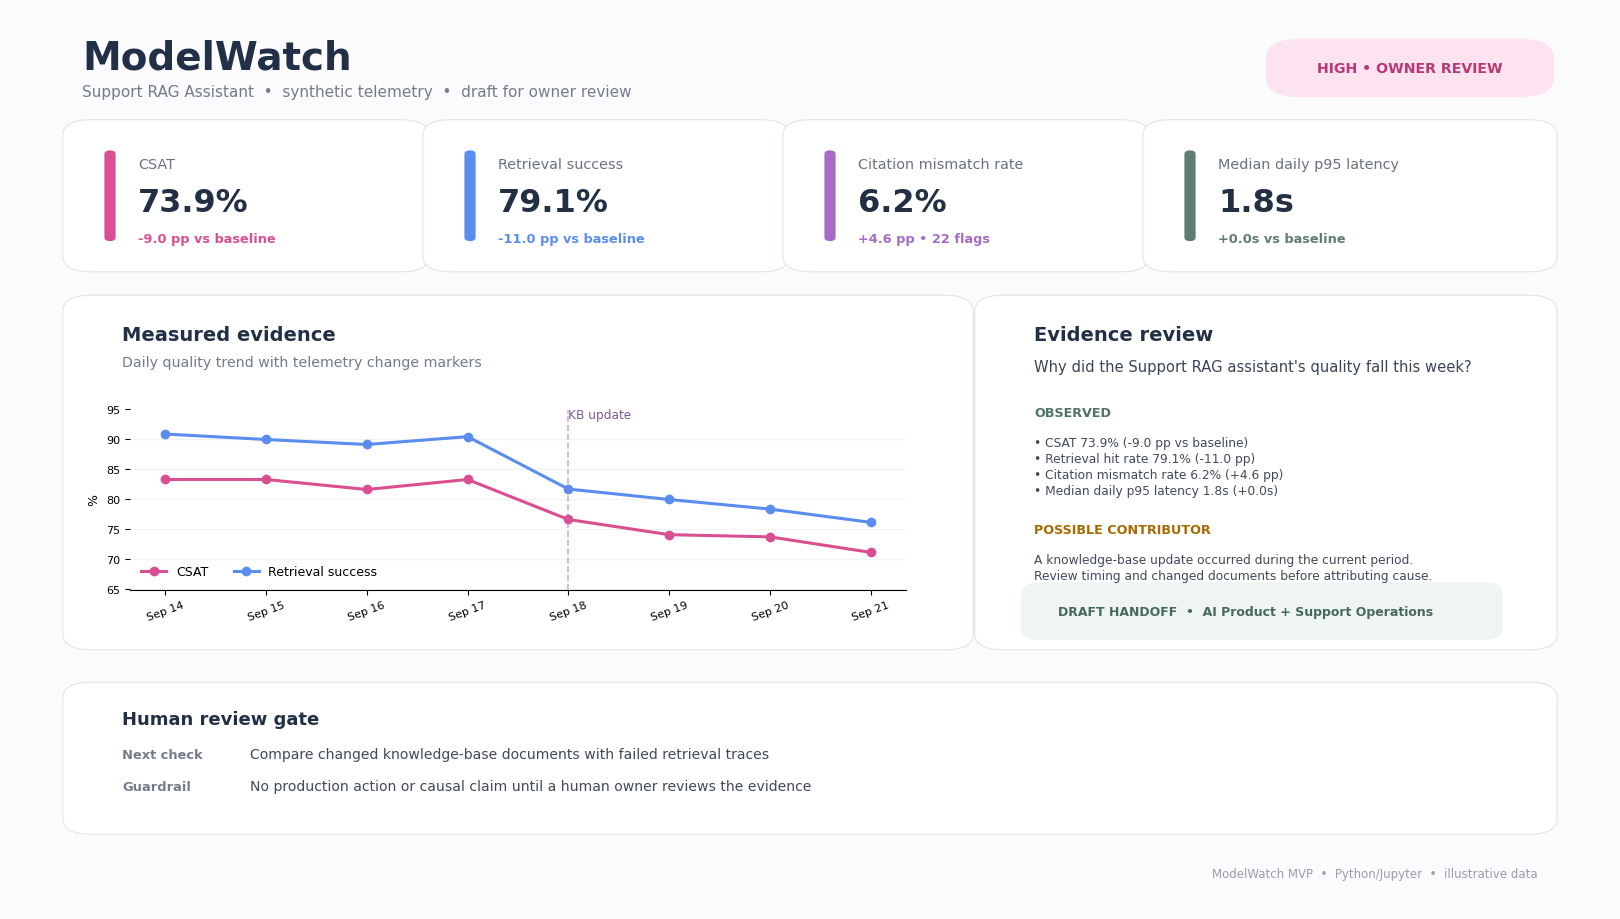

In [ ]:
import matplotlib.dates as mdates


def add_card(ax, x, y, w, h, title, value, detail, accent='#D94F91'):
    card = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.012,rounding_size=0.018',
        linewidth=0.8,
        edgecolor='#E8E2EA',
        facecolor='white'
    )
    ax.add_patch(card)

    accent_bar = FancyBboxPatch(
        (x + 0.014, y + 0.022),
        0.007,
        h - 0.044,
        boxstyle='round,pad=0,rounding_size=0.004',
        linewidth=0,
        facecolor=accent
    )
    ax.add_patch(accent_bar)

    text_x = x + 0.035

    ax.text(
        text_x,
        y + h * 0.74,
        title,
        fontsize=10.4,
        color='#6B7280',
        weight='medium',
        va='center'
    )

    ax.text(
        text_x,
        y + h * 0.45,
        value,
        fontsize=23,
        color='#233044',
        weight='bold',
        va='center'
    )

    ax.text(
        text_x,
        y + h * 0.17,
        detail,
        fontsize=9.3,
        color=accent,
        weight='semibold',
        va='center'
    )


def make_dashboard(
    df,
    incident,
    save_path='modelwatch_prototype.png'
):
    fig = plt.figure(
        figsize=(16, 9),
        facecolor='#FBFAFC'
    )

    ax = fig.add_axes([0, 0, 1, 1])

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    cur = incident['current']
    d = incident['deltas']

    # ---------------------------------------------------------
    # Header
    # ---------------------------------------------------------
    ax.text(
        0.045,
        0.946,
        'ModelWatch',
        fontsize=28,
        weight='bold',
        color='#223047',
        va='center'
    )

    ax.text(
        0.045,
        0.908,
        'Support RAG Assistant  •  synthetic telemetry  •  draft for owner review',
        fontsize=11,
        color='#747C8C',
        va='center'
    )

    severity = incident['severity']

    if severity == 'High':
        pill_text = 'HIGH • OWNER REVIEW'
        pill_face = '#FCE3EF'
        pill_text_color = '#B93873'

    elif severity == 'Medium':
        pill_text = 'MEDIUM • OWNER REVIEW'
        pill_face = '#FFF1D9'
        pill_text_color = '#9A6500'

    elif severity == 'No incident':
        pill_text = 'NO INCIDENT'
        pill_face = '#EAF6F0'
        pill_text_color = '#4E7465'

    else:
        pill_text = 'BLOCKED'
        pill_face = '#EEF0F4'
        pill_text_color = '#5D6675'

    pill = FancyBboxPatch(
        (0.795, 0.912),
        0.16,
        0.045,
        boxstyle='round,pad=0.01,rounding_size=0.022',
        linewidth=0,
        facecolor=pill_face
    )

    ax.add_patch(pill)

    ax.text(
        0.875,
        0.934,
        pill_text,
        fontsize=10.2,
        color=pill_text_color,
        ha='center',
        va='center',
        weight='bold'
    )

    # ---------------------------------------------------------
    # Metric cards
    # ---------------------------------------------------------
    add_card(
        ax,
        0.045,
        0.72,
        0.205,
        0.145,
        'CSAT',
        f"{cur['csat_pct']:.1f}%",
        f"{d['csat_pp']:+.1f} pp vs baseline",
        accent='#D94F91'
    )

    add_card(
        ax,
        0.27,
        0.72,
        0.205,
        0.145,
        'Retrieval success',
        f"{cur['retrieval_hit_pct']:.1f}%",
        f"{d['retrieval_pp']:+.1f} pp vs baseline",
        accent='#5A8DEE'
    )

    add_card(
        ax,
        0.495,
        0.72,
        0.205,
        0.145,
        'Citation mismatch rate',
        f"{cur['citation_mismatch_pct']:.1f}%",
        (
            f"{d['citation_mismatch_pp']:+.1f} pp • "
            f"{cur['citation_mismatch_flags']} flags"
        ),
        accent='#A66BC7'
    )

    add_card(
        ax,
        0.72,
        0.72,
        0.235,
        0.145,
        'Median daily p95 latency',
        f"{cur['median_daily_p95_latency_s']:.1f}s",
        f"{d['latency_s']:+.1f}s vs baseline",
        accent='#5F7D70'
    )

    # ---------------------------------------------------------
    # Measured evidence card
    # ---------------------------------------------------------
    chart_card = FancyBboxPatch(
        (0.045, 0.30),
        0.545,
        0.37,
        boxstyle='round,pad=0.012,rounding_size=0.018',
        linewidth=0.8,
        edgecolor='#E8E2EA',
        facecolor='white'
    )

    ax.add_patch(chart_card)

    ax.text(
        0.07,
        0.632,
        'Measured evidence',
        fontsize=14,
        color='#223047',
        weight='bold'
    )

    ax.text(
        0.07,
        0.603,
        'Daily quality trend with telemetry change markers',
        fontsize=10.2,
        color='#747C8C'
    )

    chart = fig.add_axes(
        [0.075, 0.355, 0.485, 0.20],
        facecolor='white'
    )

    chart.plot(
        df['date'],
        df['csat_pct'],
        marker='o',
        linewidth=2.2,
        color='#D94F91',
        label='CSAT'
    )

    chart.plot(
        df['date'],
        df['retrieval_hit_pct'],
        marker='o',
        linewidth=2.2,
        color='#5A8DEE',
        label='Retrieval success'
    )

    # Read KB update dates from the telemetry itself.
    update_dates = (
        df.loc[
            df['kb_updates'] > 0,
            'date'
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    for i, update_date in enumerate(update_dates):

        chart.axvline(
            update_date,
            linestyle='--',
            linewidth=1.2,
            color='#A66BC7',
            alpha=0.55
        )

        chart.text(
            update_date,
            93.0 - (i * 1.2),
            'KB update',
            fontsize=8.7,
            color='#7D5B93',
            ha='left',
            va='bottom'
        )

    chart.set_ylim(65, 95)

    chart.set_ylabel(
        '%',
        fontsize=9
    )

    chart.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %d')
    )

    chart.grid(
        axis='y',
        alpha=0.16
    )

    chart.spines[
        ['top', 'right', 'left']
    ].set_visible(False)

    chart.tick_params(
        axis='x',
        labelrotation=20,
        labelsize=8
    )

    chart.tick_params(
        axis='y',
        labelsize=8
    )

    chart.legend(
        frameon=False,
        fontsize=9,
        ncol=2,
        loc='lower left'
    )

    # ---------------------------------------------------------
    # Evidence review card
    # ---------------------------------------------------------
    right = FancyBboxPatch(
        (0.615, 0.30),
        0.34,
        0.37,
        boxstyle='round,pad=0.012,rounding_size=0.018',
        linewidth=0.8,
        edgecolor='#E8E2EA',
        facecolor='white'
    )

    ax.add_patch(right)

    ax.text(
        0.64,
        0.632,
        'Evidence review',
        fontsize=14,
        color='#223047',
        weight='bold'
    )

    ax.text(
        0.64,
        0.598,
        incident['question'],
        fontsize=10.6,
        color='#3B4557',
        weight='medium'
    )

    ax.text(
        0.64,
        0.548,
        'OBSERVED',
        fontsize=9.2,
        color='#4E7465',
        weight='bold'
    )

    # Pull measured statements directly from the incident object.
    observed_text = '\n'.join(
        f"• {item}"
        for item in incident.get(
            'observed',
            []
        )
    )

    ax.text(
        0.64,
        0.525,
        observed_text,
        fontsize=8.8,
        color='#41495B',
        va='top',
        linespacing=1.28
    )

    ax.text(
        0.64,
        0.418,
        'POSSIBLE CONTRIBUTOR',
        fontsize=9.2,
        color='#A66A00',
        weight='bold'
    )

    possible = incident.get(
        'possible_contributors',
        []
    )

    possible_text = (
        possible[0]
        if possible
        else (
            'No specific contributor is identified '
            'by the current telemetry.'
        )
    )

    ax.text(
        0.64,
        0.395,
        textwrap.fill(
            possible_text,
            62
        ),
        fontsize=8.8,
        color='#41495B',
        va='top',
        linespacing=1.28
    )

    # Pull owner from incident object.
    # The handoff remains explicitly draft-only.
    owner_box = FancyBboxPatch(
        (0.64, 0.307),
        0.285,
        0.048,
        boxstyle='round,pad=0.008,rounding_size=0.012',
        linewidth=0,
        facecolor='#EEF5F2'
    )

    ax.add_patch(owner_box)

    ax.text(
        0.655,
        0.331,
        f"DRAFT HANDOFF  •  {incident['owner']}",
        fontsize=9.0,
        color='#46695C',
        weight='bold',
        va='center'
    )

    # ---------------------------------------------------------
    # Human review gate
    # ---------------------------------------------------------
    footer = FancyBboxPatch(
        (0.045, 0.095),
        0.91,
        0.145,
        boxstyle='round,pad=0.012,rounding_size=0.018',
        linewidth=0.8,
        edgecolor='#E8E2EA',
        facecolor='white'
    )

    ax.add_patch(footer)

    ax.text(
        0.07,
        0.205,
        'Human review gate',
        fontsize=13,
        color='#223047',
        weight='bold'
    )

    has_kb_update = bool(
        (df['kb_updates'] > 0).any()
    )

    if has_kb_update:

        next_check = (
            'Compare changed knowledge-base documents '
            'with failed retrieval traces'
        )

    else:

        next_check = (
            'Review failed traces and recent system '
            'changes before taking action'
        )

    ax.text(
        0.07,
        0.168,
        'Next check',
        fontsize=9.4,
        color='#747C8C',
        weight='bold'
    )

    ax.text(
        0.15,
        0.168,
        next_check,
        fontsize=10.1,
        color='#41495B'
    )

    ax.text(
        0.07,
        0.132,
        'Guardrail',
        fontsize=9.4,
        color='#747C8C',
        weight='bold'
    )

    ax.text(
        0.15,
        0.132,
        (
            'No production action or causal claim '
            'until a human owner reviews the evidence'
        ),
        fontsize=10.1,
        color='#41495B'
    )

    ax.text(
        0.955,
        0.035,
        (
            'ModelWatch MVP  •  Python/Jupyter  •  '
            'illustrative data'
        ),
        fontsize=8.5,
        color='#9A9EAA',
        ha='right'
    )

    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches='tight',
        facecolor=fig.get_facecolor()
    )

    plt.show()


make_dashboard(
    data,
    incident
)

## What this prototype proves and what it does not

The notebook demonstrates that ModelWatch's core Week 4 workflow can be represented with a small, inspectable data pipeline. It can validate telemetry, summarize baseline versus current behavior, classify incident severity, and produce an owner-review draft. The causal explanation remains deliberately limited. A production version would replace the CSV with real evaluation traces and monitoring connectors, use stronger statistical or ML drift detection, and add a reviewed generative explanation step only after the evidence pipeline is reliable.
